In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn import functional as F
from torchinfo import summary
import tqdm
from matplotlib import pyplot as plt

In [2]:
# The little Shakespeare dataset 
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-02-22 20:21:54--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.05s   

2026-02-22 20:21:54 (20.7 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [3]:
# read the data in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [4]:
print(f'Text size: {len(text)}')
print('Text example:')
print(text[:300])

Text size: 1115394
Text example:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [5]:
# use sybmols as tokens
# decode and encode functions use number of the sybol in sorted order
vocab = sorted(list(set(text)))

stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for i, ch in enumerate(vocab)}

encode = lambda s: [stoi[ch] for ch in s]
decode = lambda a: ''.join([itos[i] for i in a])

In [6]:
print(vocab)

s = 'hello world'
print(encode(s))
print(decode(encode(s)))

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
[46, 43, 50, 50, 53, 1, 61, 53, 56, 50, 42]
hello world


In [7]:
# prepare train and validation data
data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

In [8]:
train_data[:100]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59])

In [9]:
torch.manual_seed(1337)

def generate_batch(batch_size: int, block_size: int, device: str, split='train') -> torch.Tensor:
    data = train_data if split == 'train' else val_data
    idx = torch.randint(len(data) - block_size, (batch_size, ))
    x = torch.stack([data[i:i + block_size] for i in idx])
    x = x.to(device)
    y = torch.stack([data[i + 1:i + 1 + block_size] for i in idx])
    y = y.to(device)
    return x, y

In [10]:
VOCAB_SIZE = len(vocab)
BATCH_SIZE = 32
BLOCK_SIZE = 32
MODEL_SIZE = 128
HEADS_NUMBER = 4
QUERIES_PER_HEAD = 2
LAYERS_NUMBER = 4

In [26]:
class QueryHead(nn.Module):

    def __init__(self, model_size, head_size, sequence_len, key_projs, value_projs, device):
        super().__init__()

        self.query = nn.Linear(model_size, head_size)
        self.key = key_projs
        self.value = value_projs
        self.dropout = nn.Dropout(0.1)
        self.model_size = model_size
        self.tril = torch.tril(
            torch.ones((sequence_len, sequence_len),
                       dtype=torch.float, device=device))

    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, model_size = x.shape
        q = self.query(x) # (B, T, head_size)
        k = self.key(x) # (B, T, head_size)
        v = self.value(x) # (B, T, head_size)

        weights = q @ k.transpose(1, 2) / self.model_size**0.5 # (B, T, T)
        weights = torch.masked_fill(weights, self.tril[:T, :T] == 0, float('-inf'))
        weights = torch.softmax(weights, dim=-1)
        weights = self.dropout(weights)

        out = weights @ v # (B, T, head_size)
        return out


class GroupedQueryHead(nn.Module):

    def __init__(self, model_size, head_size, queries_per_head, sequence_len, device):
        super().__init__()

        query_head_size = head_size // queries_per_head
        self.key = nn.Linear(model_size, query_head_size)
        self.value = nn.Linear(model_size, query_head_size)
        self.query_heads = nn.ModuleList([
            QueryHead(model_size, query_head_size, sequence_len, self.key, self.value, device) 
            for _ in range(queries_per_head)])


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = torch.cat([qh(x) for qh in self.query_heads], dim=-1)
        return out
        

class GroupedQueryAttention(nn.Module):

    def __init__(self, model_size, heads_number, queries_per_head, sequence_len, device):
        super().__init__()

        head_size = model_size // heads_number
        self.attention_blocks = nn.ModuleList([
            GroupedQueryHead(model_size, head_size, queries_per_head, sequence_len, device) 
            for _ in range(heads_number)])
        self.projection = nn.Linear(model_size, model_size)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        blocks_out = torch.cat([att(x) for att in self.attention_blocks], dim=-1)
        out = self.projection(blocks_out)
        return out


class GatedGroupedQueryAttention(nn.Module):
    
    def __init__(self, model_size, heads_number, queries_per_head, sequence_len, device):
        super().__init__()

        self.gqa = GroupedQueryAttention(model_size, heads_number, queries_per_head, sequence_len, device)
        self.gate = nn.Sequential(
            nn.Linear(model_size, model_size),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        attention_out = self.gqa(x)
        gate_out = self.gate(x)

        return gate_out * attention_out + (1 - gate_out) * x
    
        

class FeedForward(nn.Module):

    def __init__(self, model_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(model_size, model_size),
            nn.ReLU(),
            nn.Linear(model_size, model_size))


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Block(nn.Module):

    def __init__(self, sequnce_len, model_size, heads_number, queries_per_head, device):
        super().__init__()

        self.self_attention = GatedGroupedQueryAttention(model_size, heads_number, queries_per_head, sequnce_len, device)
        self.layer_norm_sa = nn.LayerNorm(model_size)
        self.layer_norm_ffn = nn.LayerNorm(model_size)
        self.ffn = FeedForward(model_size)

    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        sa_out = x + self.self_attention(self.layer_norm_sa(x))
        ffn_out = sa_out + self.ffn(self.layer_norm_ffn(sa_out))
        return ffn_out


class TinyShakespearModel(nn.Module):

    def __init__(self, device):
        super().__init__()
        
        # Token embedings
        self.token_embeddings_table = nn.Embedding(VOCAB_SIZE, MODEL_SIZE, device=device)

        self.positions = torch.arange(MODEL_SIZE, device=device)
        # Learned position encoding
        self.position_embeddings_table = nn.Embedding(BLOCK_SIZE, MODEL_SIZE, device=device)

        # Model blocks
        self.block = nn.Sequential(
            *[Block(BLOCK_SIZE, MODEL_SIZE, HEADS_NUMBER, QUERIES_PER_HEAD, device) 
              for _ in range(LAYERS_NUMBER)])
        self.lm_head = nn.Linear(MODEL_SIZE, VOCAB_SIZE)

        
    def forward(self, x: torch.Tensor, targets: torch.Tensor | None = None) -> torch.Tensor:
        B, T = x.shape

        token_emb = self.token_embeddings_table(x) # (B, T, D)
        position_emb = self.position_embeddings_table(self.positions[:T]) # (T, D)

        logits = self.lm_head(self.block(token_emb + position_emb)) 

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))

        return logits, loss


    def generate(self, x: torch.Tensor, tokens_number: int) -> torch.Tensor:
        for _ in range(tokens_number):
            x_block = x[:, -BLOCK_SIZE:]
            logits, loss = self(x_block)
            # take only the last predictions
            last_token_logits = logits[:, -1, :]
            # get probabilities
            probs = F.softmax(last_token_logits, dim=-1)
            # sample new token from the distribution
            new_token = torch.multinomial(probs, num_samples=1)
            x = torch.cat((x, new_token), dim=1)
        return x

100%|██████████| 200/200 [00:08<00:00, 22.35it/s]


overfit loss 0.00014068176096770912


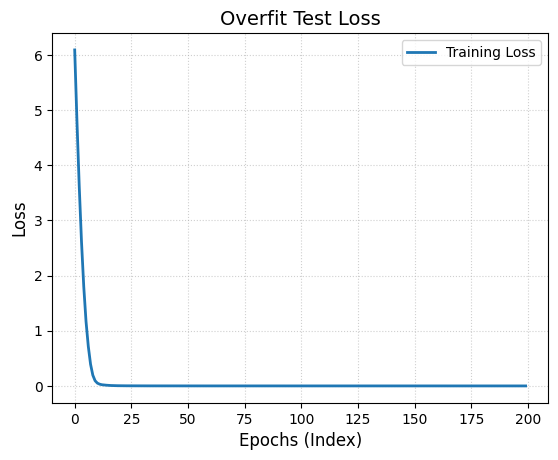

In [27]:
# overfit test to ensure the model is set up correctly
overfit_device = 'cpu'
m = TinyShakespearModel(overfit_device)
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)
x, y = generate_batch(1, BLOCK_SIZE, overfit_device)
steps = 150

losses_overfit = []
for _ in tqdm.tqdm(range(steps)):
    logits, loss = m(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    losses_overfit.append(loss.item())

print('overfit loss', losses_overfit[-1])

epochs = range(len(losses_overfit)) 

plt.plot(epochs, losses_overfit, label='Training Loss', color='tab:blue', linewidth=2)

plt.title('Overfit Test Loss', fontsize=14)
plt.xlabel('Epochs (Index)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

In [28]:
# creating a model
device = 'cuda:0'
model = TinyShakespearModel(device)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [29]:
# training the model
steps = 15000
losses = []
val_losses = []

for i in tqdm.tqdm(range(steps)):
    x, y = generate_batch(BATCH_SIZE, BLOCK_SIZE, device, split='train')
    logits, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    with torch.no_grad():
        x, y = generate_batch(BATCH_SIZE, BLOCK_SIZE, device, split='val')
        logits, loss = model(x, y)
        val_losses.append(loss.item())

100%|██████████| 15000/15000 [15:14<00:00, 16.40it/s]


In [30]:
print('train loss', losses[-1], 'val loss', val_losses[-1])

train loss 1.4307825565338135 val loss 1.779207706451416


# Results

### MHA model with hyperparameners:

BATCH_SIZE = 32, BLOCK_SIZE = 32, MODEL_SIZE = 128, HEADS_NUMBER = 8, LAYERS_NUMBER = 4

In [18]:
x, y = generate_batch(BATCH_SIZE, BLOCK_SIZE, device)
summary(model, input_data=x)

Layer (type:depth-idx)                             Output Shape              Param #
TinyShakespearModel                                [32, 32, 65]              --
├─Embedding: 1-1                                   [32, 32, 128]             8,320
├─Embedding: 1-2                                   [32, 128]                 4,096
├─Sequential: 1-3                                  [32, 32, 128]             --
│    └─Block: 2-1                                  [32, 32, 128]             --
│    │    └─LayerNorm: 3-1                         [32, 32, 128]             256
│    │    └─MultiHeadAttention: 3-2                [32, 32, 128]             66,048
│    │    └─LayerNorm: 3-3                         [32, 32, 128]             256
│    │    └─FeedForward: 3-4                       [32, 32, 128]             33,024
│    └─Block: 2-2                                  [32, 32, 128]             --
│    │    └─LayerNorm: 3-5                         [32, 32, 128]             256
│    │    └─MultiH

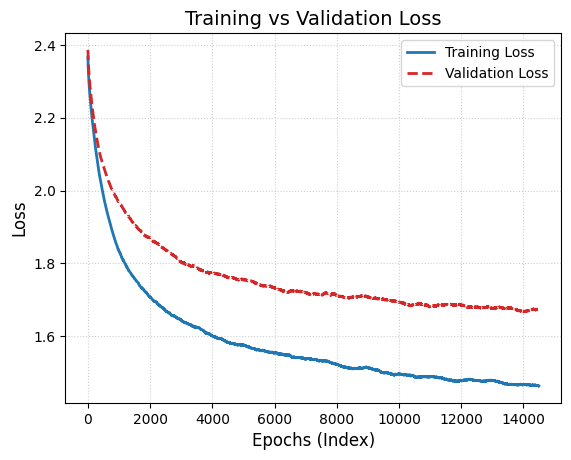

In [19]:
N = 500
rolling_avg_losses = np.convolve(losses, np.ones(N)/N, mode='valid')
rolling_avg_val_losses = np.convolve(val_losses, np.ones(N)/N, mode='valid')

epochs = range(len(rolling_avg_losses)) 

plt.plot(epochs, rolling_avg_losses, label='Training Loss', color='tab:blue', linewidth=2)
plt.plot(epochs, rolling_avg_val_losses, label='Validation Loss', color='tab:red', linestyle='--', linewidth=2)

plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs (Index)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

In [22]:
# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, tokens_number=1000)[0].tolist()))


the mather but wollow my brother priches Blandush'd my wrongbod lords,
I Love hide addointes and thise
My Roman:
There it, dust he would Slain Malshollent:
He but as worsh that I weepse; and but it with a power,
Sound 'tis gone and who else her I nor prevesence;
That wret here disgriming Aumerle cold:
You speak not, and parts discously:
Tne have I will will prefect and ground
And I have with graw follow a sir.

RUTLAND:
Thou wilt go anoint a thright, pair death:
Why, teemine han hands, no fetch
Nor we dishrone house that night, uncle it?
Or no impression: the is the kingher of must;
Agarise we asboss ancourage of voice at prequies.

ABHORSON:
Remed up you presemain'd.

FLORIZEL:
Why, or says the head mother children'd. Hath set
Thine own must be hundred with of your disdain
With very his ghoseful young him?

NORTHUMBERLARD:
Speak not shout in his morementer
Which no Geone haply man, that see thou know
Ploans to my will wayman: 'twill have dead stands
Being wall in the hate has inter'd

### GQA model with hyperparameners:

BATCH_SIZE = 32, SEQUENCE_LEN = 32, MODEL_SIZE = 128, HEADS_NUMBER = 4, QUERIES_PER_HEAD = 2, LAYERS_NUMBER = 4

In [16]:
x, y = generate_batch(BATCH_SIZE, BLOCK_SIZE, device)
summary(model, input_data=x)

Layer (type:depth-idx)                                  Output Shape              Param #
TinyShakespearModel                                     [32, 32, 65]              --
├─Embedding: 1-1                                        [32, 32, 128]             8,320
├─Embedding: 1-2                                        [32, 128]                 4,096
├─Sequential: 1-3                                       [32, 32, 128]             --
│    └─Block: 2-1                                       [32, 32, 128]             --
│    │    └─LayerNorm: 3-1                              [32, 32, 128]             256
│    │    └─GroupedQueryAttention: 3-2                  [32, 32, 128]             49,536
│    │    └─LayerNorm: 3-3                              [32, 32, 128]             256
│    │    └─FeedForward: 3-4                            [32, 32, 128]             33,024
│    └─Block: 2-2                                       [32, 32, 128]             --
│    │    └─LayerNorm: 3-5                  

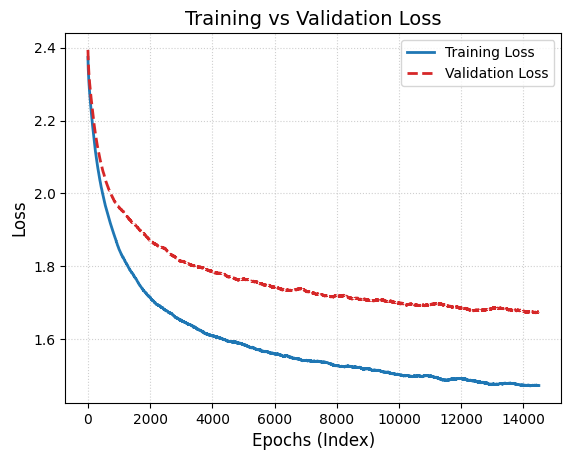

In [21]:
N = 500
gqa_rolling_avg_losses = np.convolve(losses, np.ones(N)/N, mode='valid')
gqa_rolling_avg_val_losses = np.convolve(val_losses, np.ones(N)/N, mode='valid')

epochs = range(len(rolling_avg_losses)) 

plt.plot(epochs, gqa_rolling_avg_losses, label='Training Loss', color='tab:blue', linewidth=2)
plt.plot(epochs, gqa_rolling_avg_val_losses, label='Validation Loss', color='tab:red', linestyle='--', linewidth=2)

plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs (Index)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

In [18]:
print('train loss', losses[-1], 'val loss', val_losses[-1])

train loss 1.4325025081634521 val loss 1.6092584133148193


In [19]:
# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, tokens_number=1000)[0].tolist()))


the man your ordshaperabel frounes,
And made I speak: the rebot me oft:
prive a dispatched such and sea, both ends why strady.

DUKE OF YORK:
For that I dreat butter worsy than
Is emprous of Yorking oath brother one of,
Well!
My breasom, as I steel forbears, and,
have needs, ned, grief he well not your breat to pitchance.

GLOUCESTER:
I dnever I swould with them doth skilf there
wencher, crief loves the sword: when I say you will go an is last the entree
Hang win thou see held he'll be noble to under,
I saw no forb and win! love you tick tain times? 
WAR:
If thou, for I am too murder.

EXTAUS:
We'll say't he calls of the now.

HENRY BOLINGBROKE:
Tell he uspired at you? mell is that should live me
Shappy years to him do the long? will I speak not here's son another
purposes and and garel upon'd with the hing houses giving Angelo:
On the tremned's emore than
Contod's leeding.

KING LEWARD IV:
Sonow you must abacry Tarquiet the gades on sounds!
And, not still stands, but in where is 'Two

In [20]:
torch.save(model.state_dict(), 'gqa_model.pth')

### Gated GQA with the same hyperparameters

In [31]:
x, y = generate_batch(BATCH_SIZE, BLOCK_SIZE, device)
summary(model, input_data=x)

Layer (type:depth-idx)                                       Output Shape              Param #
TinyShakespearModel                                          [32, 32, 65]              --
├─Embedding: 1-1                                             [32, 32, 128]             8,320
├─Embedding: 1-2                                             [32, 128]                 4,096
├─Sequential: 1-3                                            [32, 32, 128]             --
│    └─Block: 2-1                                            [32, 32, 128]             --
│    │    └─LayerNorm: 3-1                                   [32, 32, 128]             256
│    │    └─GatedGroupedQueryAttention: 3-2                  [32, 32, 128]             66,048
│    │    └─LayerNorm: 3-3                                   [32, 32, 128]             256
│    │    └─FeedForward: 3-4                                 [32, 32, 128]             33,024
│    └─Block: 2-2                                            [32, 32, 128]     

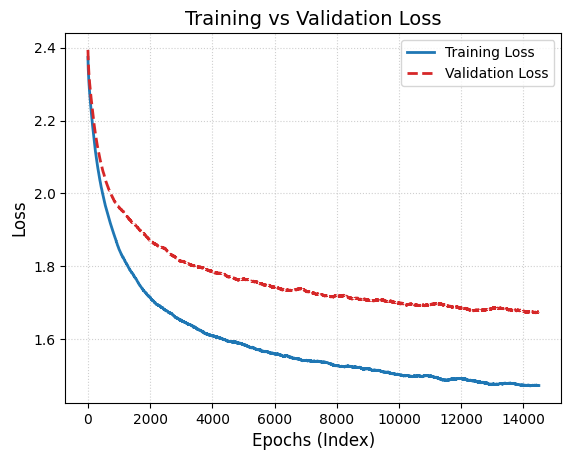

In [32]:
N = 500
gated_gqa_rolling_avg_losses = np.convolve(losses, np.ones(N)/N, mode='valid')
gated_gqa_rolling_avg_val_losses = np.convolve(val_losses, np.ones(N)/N, mode='valid')

epochs = range(len(rolling_avg_losses)) 
plt.plot(epochs, gqa_rolling_avg_losses, label='Training Loss', color='tab:blue', linewidth=2)
plt.plot(epochs, gqa_rolling_avg_val_losses, label='Validation Loss', color='tab:red', linestyle='--', linewidth=2)

plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs (Index)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

In [33]:
print('train loss', losses[-1], 'val loss', val_losses[-1])

train loss 1.4307825565338135 val loss 1.779207706451416


In [34]:
# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, tokens_number=1000)[0].tolist()))



RICHARD:
I'll heard you have no unto thy news.

Nurse:
I both mistern, I mistres, with gentle.
Cut say to throw nettle and look and war;
And in't good for conquit any how; to thee
But by made not dake it both so: my last
That I cannot well, thought with the nept.
There's the advertators, their true now,
Wher, often kill be-untreat's govern to me spray'd unmakes, my pover, my friends. Bash'd you more.

NORTHUMBERLAND:
Had you thou not. Promise, so, thou stittle purse.
Should there in a resolucking, for such is look drown;
To had monto. Thy kind win, for might hath tmorch heartils,
So residence iWht woo? why cout 'twixt fly were
Take thy each her doubt: so you go's his
Apolliar to o life many forwariar?

TYBALT:
Go afford, so the honour of unto him ever end bitted, I wank patting if the fall;
Have thou strest your kind kind crow they
that have step to other best, with not till me now;
His that dream hope of sweeter, Yearth:
It go and art thurst this unto strive accitor to have as at eq

In [36]:
torch.save(model.state_dict(), 'gated_gqa_model.pth')